In [1]:
# =============================================
# IMPORTY
# =============================================
import os
import sys
import math

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel



if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")

# Nastav working directory na kořen projektu
_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f"✓ Working directory: {os.getcwd()}")
# PFNs — musí být naklonováno (viz setup.sh)
from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

print("✓ PFNs načteny")

✓ Device: mps
✓ PyTorch: 2.10.0
✓ Working directory: /Users/ruslanguliev/VU_RG
✓ PFNs načteny


In [2]:
# =============================================
# LOAD HELPER 
# =============================================

def load_pfn_model(checkpoint_path, device='cpu'):
    """
    Načte PFN model z checkpointu. Podporuje tři formáty:

    1. Nový formát (MainConfig dict, 'priors' key):
       - Uloženo přes epoch loop v PFN_TRAIN_SETUP.ipynb nebo pfn_train*.py
       - Config obsahuje celou architekturu → nlayers, emsize atd. se čtou automaticky

    2. Starý formát ('hps' key):
       - Uloženo přes train_gp_pfn()
       - Config obsahuje jen HP, architektura se musí rekonstruovat
       - nlayers se pokusí přečíst z config; pokud chybí, vyhodí chybu

    Vrací: (model, hps, epoch)
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Model nenalezen: {checkpoint_path}\n")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config_data = checkpoint.get('config', {})

    # --- Formát 1: MainConfig dict (nový) ---
    if isinstance(config_data, dict) and 'priors' in config_data:
        saved_config = MainConfig.from_dict(config_data)
        model = saved_config.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
        hps = saved_config.priors[0].prior_kwargs.get('hyperparameters', {})
        epoch = checkpoint.get('epoch', '?')

    # --- Formát 2: starý formát ('hps' key) ---
    elif isinstance(config_data, dict) and 'hps' in config_data:
        hps = config_data['hps']
        epoch = config_data.get('epochs', checkpoint.get('epoch', '?'))
        criterion = checkpoint['criterion']

        nlayers = config_data.get('nlayers')
        if nlayers is None:
            # Odvoď nlayers ze state_dict — spočítej nejvyšší index vrstvy
            layer_indices = [
                int(k.split('.')[2])
                for k in checkpoint['model_state_dict']
                if k.startswith('transformer_layers.layers.')
            ]
            nlayers = max(layer_indices) + 1 if layer_indices else 6

        emsize  = config_data.get('emsize',  512)
        nhead   = config_data.get('nhead',   8)
        nhid    = config_data.get('nhid',    1024)

        cfg = MainConfig(
            priors=[AdhocPriorConfig(
                get_batch_methods=[get_batch_for_gp],
                prior_kwargs={'num_features': 1, 'hyperparameters': hps}
            )],
            optimizer=OptimizerConfig('adamw', lr=0.0003),
            model=TransformerConfig(
                criterion=BarDistributionConfig(
                    full_support=True,
                    borders=criterion.borders.tolist()
                ),
                emsize=emsize, nhead=nhead, nhid=nhid, nlayers=nlayers,
                features_per_group=1,
                attention_between_features=False,
                encoder=EncoderConfig(
                    constant_normalization_mean=0.5,
                    constant_normalization_std=math.sqrt(1/12)
                )
            ),
            batch_shape_sampler=BatchShapeSamplerConfig(
                batch_size=64, max_seq_len=50,
                min_num_features=1, max_num_features=1
            ),
            epochs=1, warmup_epochs=0,
            steps_per_epoch=1, num_workers=0,
        )
        model = cfg.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
        model.criterion = criterion

    else:
        raise ValueError(f"Neznámý formát checkpointu. Klíče config: {list(config_data.keys())}")

    model.to(device)
    model.eval()
    print(f"✓ Model načten: {os.path.basename(checkpoint_path)}")
    print(f"  Epocha: {epoch}, nlayers: {nlayers if 'nlayers' in dir() else '(z MainConfig)'}")
    print(f"  Parametrů: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")
    return model, hps, epoch

print("✓ load_pfn_model připraven")

✓ load_pfn_model připraven


In [3]:
# =============================================
# NAČTENÍ MODELŮ
# =============================================
# DŮLEŽITÉ: get_batch_for_gp_random_hps musí být definována PŘED torch.load
# (checkpoint ji pickle-uje jako referenci)

def get_batch_for_gp_random_hps(batch_size, seq_len, num_features,
                                 device='cpu', hyperparameters=None, **kwargs):
    # Fixní HP — používáno pouze pro dummy train() při sestavení architektury
    hps = {"lengthscale": 0.3, "outputscale": 0.1, "noise": 1.0}
    return get_batch_for_gp(batch_size, seq_len, num_features,
                             device=device, hyperparameters=hps, **kwargs)


def load_for_inference(checkpoint_path, device='cpu'):
    """
    Načte PFN checkpoint pro inferenci.
    Podporuje nový formát (klíč 'priors') i starý formát (klíč 'num_features').
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config = checkpoint['config']

    if 'num_features' in config:
        # Starý formát
        num_features     = config['num_features']
        max_dataset_size = config['max_dataset_size']
        criterion        = checkpoint['criterion']
        borders          = criterion.borders.tolist()
        nlayers          = config.get('nlayers', 6)
        get_batch_fn     = get_batch_for_gp
        prior_kwargs     = {'num_features': num_features,
                            'hyperparameters': config.get('hps', {})}
    else:
        # Nový formát (MainConfig)
        num_features     = config['priors'][0]['prior_kwargs']['num_features']
        max_dataset_size = config['batch_shape_sampler']['max_seq_len']
        borders          = config['model']['criterion']['borders']
        nlayers          = config['model'].get('nlayers', 6)
        get_batch_fn     = get_batch_for_gp_random_hps
        prior_kwargs     = {'num_features': num_features, 'hyperparameters': {}}
        criterion        = None

    model_config = MainConfig(
        priors=[AdhocPriorConfig(
            get_batch_methods=[get_batch_fn],
            prior_kwargs=prior_kwargs
        )],
        optimizer=OptimizerConfig('adamw', lr=0.0003),
        model=TransformerConfig(
            criterion=BarDistributionConfig(full_support=True, borders=borders),
            emsize=512, nhead=8, nhid=1024, nlayers=nlayers,
            features_per_group=1, attention_between_features=False,
            encoder=EncoderConfig(
                constant_normalization_mean=0.5,
                constant_normalization_std=math.sqrt(1/12)
            )
        ),
        batch_shape_sampler=BatchShapeSamplerConfig(
            batch_size=2, max_seq_len=max_dataset_size,
            min_num_features=num_features, max_num_features=num_features
        ),
        epochs=1, steps_per_epoch=1, num_workers=0,
    )

    dummy_result = train(model_config, device=device, reusable_config=False)
    model = dummy_result['model']
    model.load_state_dict(checkpoint['model_state_dict'])
    if criterion is not None:
        model.criterion = criterion
    model.to(device)
    model.eval()

    epoch = checkpoint.get('epoch', '?')
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  ✓ {os.path.basename(checkpoint_path)}: nlayers={nlayers}, epoch={epoch}, {n_params:.1f}M params')
    return model, epoch


# =============================================
# CESTY K MODELŮM
# =============================================
EASY_MODEL_PATHS = {
    '1-layer': os.path.join('models', 'pfn_fixed_easy', 'pfn_easy_1L.pth'),
    '2-layer': os.path.join('models', 'pfn_fixed_easy', 'pfn_easy_2L.pth'),
    '4-layer': os.path.join('models', 'pfn_fixed_easy', 'pfn_easy_4L.pth'),
    '6-layer': os.path.join('models', 'pfn_fixed_easy', 'pfn_easy_6L.pth'),
    '8-layer': os.path.join('models', 'pfn_fixed_easy', 'pfn_easy_8L.pth'),
}

HARD_MODEL_PATHS = {
    '1-layer': os.path.join('models', 'pfn_fixed_hard', 'pfn_hard_1L.pth'),
    '2-layer': os.path.join('models', 'pfn_fixed_hard', 'pfn_hard_2L.pth'),
    '4-layer': os.path.join('models', 'pfn_fixed_hard', 'pfn_hard_4L.pth'),
    '6-layer': os.path.join('models', 'pfn_fixed_hard', 'pfn_hard_6L.pth'),
    '8-layer': os.path.join('models', 'pfn_fixed_hard', 'pfn_hard_8L.pth'),
}

print('Načítám Easy modely (ℓ=0.1, noise=0.5)...')
EASY_MODELS = {}
for name, path in EASY_MODEL_PATHS.items():
    if os.path.exists(path):
        EASY_MODELS[name], _ = load_for_inference(path, device)
    else:
        print(f'  ⚠ Nenalezeno: {path}')

print('\nNačítám Hard modely (ℓ=0.5, noise=0.1)...')
HARD_MODELS = {}
for name, path in HARD_MODEL_PATHS.items():
    if os.path.exists(path):
        HARD_MODELS[name], _ = load_for_inference(path, device)
    else:
        print(f'  ⚠ Nenalezeno: {path}')

print(f'\n✓ Easy: {list(EASY_MODELS.keys())}')
print(f'✓ Hard:  {list(HARD_MODELS.keys())}')


Načítám Easy modely (ℓ=0.1, noise=0.5)...
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparamet

/Users/ruslanguliev/VU_RG/PFNs/pfns/train.py:238: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if c.train_mixed_precision else None


-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.39s | mean loss  1.48 | lr 0.0 | data time  0.00 step time  0.37 forward time  0.13 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_easy_1L.pth: nlayers=1, epoch=300, 3.7M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_inst

## Experiment 2: PFN jako Neumannova řada?

### Otázka (Q2)

Potřebují špatně podmíněné systémy víc vrstev PFN než dobře podmíněné?

### Neumannova řada a GP

GP posterior mean vyžaduje $(K+\sigma^2 I)^{-1}y$. Gradient descent tuto inverzi řeší iterativně:

$$\alpha^{(0)} = 0, \qquad \alpha^{(t+1)} = \alpha^{(t)} + \eta\bigl(y - (K+\sigma^2 I)\alpha^{(t)}\bigr)$$

Počet kroků pro konvergenci závisí na podmíněnosti:

$$\kappa = \frac{\lambda_{\max}(K) + \sigma^2}{\lambda_{\min}(K) + \sigma^2}$$

**Hypotéza:** Každá vrstva PFN odpovídá jednomu GD kroku → hůře podmíněné úlohy (větší κ) potřebují více vrstev.

### Konfigurace

| Regime | ℓ | noise (σ²) | outputscale | Kondice K | Trénovací HP |
|--------|---|-----------|-------------|-----------|--------------|
| Easy   | 0.1 | 0.5 | 1.0 | malá κ   | shodné s testovacími |
| Hard   | 0.5 | 0.1 | 1.0 | velká κ  | shodné s testovacími |

**Klíčová vlastnost:** Každá sada modelů je trénována **přesně na svých testovacích HP** — testujeme in-distribution výkon, nikoliv generalizaci.

### Metrika: ΔNLL a MSE

Pro každý model a každou instanci spočítáme:
$$\Delta_{\text{NLL}} = \text{NLL}_{\text{PFN}} - \text{NLL}_{\text{GP}}, \qquad \text{MSE} = \frac{1}{n_{\text{test}}}\sum_i (\hat{\mu}(x_i^*) - \mu_{\text{GP}}(x_i^*))^2$$

Průměrujeme přes 200 instancí. Graf: osa x = počet vrstev L, osa y = ΔNLL (nebo MSE), dvě křivky (easy/hard).

### Co hledat
- **Easy klesá rychle, Hard pomaleji** → potvrzení Neumannovy hypotézy
- **Obě klesají stejně** → podmíněnost není limitující faktor


In [4]:
# =============================================
# GP UTILITY FUNKCE
# =============================================

def rbf_kernel(x1, x2, lengthscale, outputscale=1.0):
    """RBF kernel: K[i,j] = outputscale * exp(-||x1[i]-x2[j]||² / 2ℓ²)"""
    dist_sq = (x1[:, None] - x2[None, :]) ** 2
    return outputscale * np.exp(-dist_sq / (2 * lengthscale**2))


def gp_exact_posterior(train_x, train_y, test_x, lengthscale, noise, outputscale=1.0):
    """
    Přesný GP posterior: střední hodnota a log-likelihood.
    Vrací: (mu_star, nll) kde nll = -log p(y_test | x_test, x_train, y_train).
    """
    K    = rbf_kernel(train_x, train_x, lengthscale, outputscale)
    Kn   = K + noise * np.eye(len(train_x))
    Ks   = rbf_kernel(test_x, train_x, lengthscale, outputscale)
    Kss  = rbf_kernel(test_x, test_x, lengthscale, outputscale)
    try:
        L = np.linalg.cholesky(Kn)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, train_y))
    except np.linalg.LinAlgError:
        alpha = np.linalg.solve(Kn, train_y)
    mu_star = Ks @ alpha
    # Posterior variance pro NLL
    v = np.linalg.solve(L, Ks.T)
    var_star = np.diag(Kss - v.T @ v) + noise
    var_star = np.maximum(var_star, 1e-8)
    # NLL = 0.5 * sum(log(2π var) + (y-mu)²/var)  — placeholder, test_y neznáme dopředu
    return mu_star, var_star


def gp_exact_posterior_mean(train_x, train_y, test_x, lengthscale, noise, outputscale=1.0):
    """Vrací pouze střední hodnotu GP posterioru."""
    mu, _ = gp_exact_posterior(train_x, train_y, test_x, lengthscale, noise, outputscale)
    return mu


def condition_number(train_x, lengthscale, noise, outputscale=1.0):
    """κ = (λ_max(K) + σ²) / (λ_min(K) + σ²)"""
    K = rbf_kernel(train_x, train_x, lengthscale, outputscale)
    ev = np.linalg.eigvalsh(K)
    lmax = ev[-1]
    lmin = max(ev[0], 0.0)
    return (lmax + noise) / (lmin + noise), lmax, lmin


def pfn_predict(model, train_x, train_y, test_x, device):
    """
    Inference PFN modelu. Vrací (mean, logits).
    train_x: (n, 1) tensor, train_y: (n,) tensor, test_x: (m, 1) tensor
    """
    with torch.no_grad():
        logits = model(
            train_x[None].to(device),
            train_y[None].to(device),
            test_x[None].to(device)
        )
    mean = model.criterion.mean(logits)[0].detach().cpu().numpy()
    return mean, logits


def compute_pfn_nll(model, train_x, train_y, test_x, test_y, device):
    """
    NLL PFN predikce na test_y.
    NLL = -log p(y_test | context) průměrovaná přes testovací body.
    """
    _, logits = pfn_predict(model, train_x, train_y, test_x, device)
    test_y_t = test_y.to(device)
    # FullSupportBarDistribution.__call__(logits, y) vrací log p(y|logits) pro každý bod
    log_prob = model.criterion(logits[0], test_y_t)
    nll = -log_prob.mean().item()
    return nll


def compute_gp_nll(train_x, train_y, test_x, test_y, lengthscale, noise, outputscale=1.0):
    """
    NLL přesného GP posterioru na test_y.
    NLL = 0.5 * mean(log(2π σ²) + (y - μ)² / σ²)
    """
    tx = train_x.numpy().reshape(-1)
    ty = train_y.numpy().reshape(-1)
    te = test_x.numpy().reshape(-1)
    ty_test = test_y.numpy().reshape(-1)
    mu, var = gp_exact_posterior(tx, ty, te, lengthscale, noise, outputscale)
    nll = 0.5 * np.mean(np.log(2 * np.pi * var) + (ty_test - mu)**2 / var)
    return nll

print('GP utility funkce připraveny')


GP utility funkce připraveny


In [5]:
# =============================================
# GENEROVÁNÍ DAT + VÝPOČET κ
# =============================================
# Data se generují jednou a sdílejí pro všechny modely — férové srovnání.

from IPython.display import display, Markdown

# HP konfigurace — shodné s trénovacími HP příslušných modelů
EASY_HPS = {'lengthscale': 0.1, 'noise': 0.5, 'outputscale': 1.0}
HARD_HPS = {'lengthscale': 0.5, 'noise': 0.1, 'outputscale': 1.0}

N_CONTEXT   = 20
N_TEST      = 10
N_INSTANCES = 200


def generate_datasets(n_instances, n_context, n_test, hps):
    """
    Generuje sdílené datasety pro fixní HP.
    Vrací: list of (train_x, train_y, test_x, test_y)
      train_x: (n_context, 1), train_y: (n_context,)
      test_x:  (n_test, 1),    test_y:  (n_test,)
    """
    datasets = []
    seq_len = n_context + n_test
    for _ in range(n_instances):
        batch = get_batch_for_gp(
            batch_size=1, seq_len=seq_len, num_features=1,
            device='cpu', hyperparameters=hps
        )
        datasets.append((
            batch.x[0, :n_context],        # train_x (n_context, 1)
            batch.y[0, :n_context],        # train_y (n_context,)
            batch.x[0, n_context:],        # test_x  (n_test, 1)
            batch.target_y[0, n_context:], # test_y  (n_test,)
        ))
    return datasets


print(f'Generuji Easy datasety (ℓ={EASY_HPS["lengthscale"]}, σ²={EASY_HPS["noise"]})...')
easy_datasets = generate_datasets(N_INSTANCES, N_CONTEXT, N_TEST, EASY_HPS)
print(f'Generuji Hard datasety (ℓ={HARD_HPS["lengthscale"]}, σ²={HARD_HPS["noise"]})...')
hard_datasets = generate_datasets(N_INSTANCES, N_CONTEXT, N_TEST, HARD_HPS)

# Výpočet κ z dat
def mean_kappa(datasets, hps, n_samples=50):
    ks = []
    for train_x, _, _, _ in datasets[:n_samples]:
        k, _, _ = condition_number(train_x.numpy().reshape(-1),
                                   hps['lengthscale'], hps['noise'], hps['outputscale'])
        ks.append(k)
    return np.mean(ks), np.std(ks)

kappa_easy, kappa_easy_std = mean_kappa(easy_datasets, EASY_HPS)
kappa_hard, kappa_hard_std = mean_kappa(hard_datasets, HARD_HPS)

display(Markdown(f"""
### Podmíněnost κ = (λ_max(K) + σ²) / (λ_min(K) + σ²) — průměr přes 50 instancí, n_context={N_CONTEXT}

| Regime | ℓ | σ² | **κ (průměr ± std)** | Míra konv. GD za krok: (κ−1)/(κ+1) |
|--------|---|----|----------------------|-------------------------------------|
| Easy   | {EASY_HPS['lengthscale']} | {EASY_HPS['noise']} | **{kappa_easy:.1f} ± {kappa_easy_std:.1f}** | {(kappa_easy-1)/(kappa_easy+1):.3f} |
| Hard   | {HARD_HPS['lengthscale']} | {HARD_HPS['noise']} | **{kappa_hard:.1f} ± {kappa_hard_std:.1f}** | {(kappa_hard-1)/(kappa_hard+1):.3f} |
"""))

print(f'\n{N_INSTANCES} instancí × (n_ctx={N_CONTEXT}, n_test={N_TEST})')


Generuji Easy datasety (ℓ=0.1, σ²=0.5)...
Generuji Hard datasety (ℓ=0.5, σ²=0.1)...



### Podmíněnost κ = (λ_max(K) + σ²) / (λ_min(K) + σ²) — průměr přes 50 instancí, n_context=20

| Regime | ℓ | σ² | **κ (průměr ± std)** | Míra konv. GD za krok: (κ−1)/(κ+1) |
|--------|---|----|----------------------|-------------------------------------|
| Easy   | 0.1 | 0.5 | **13.7 ± 1.7** | 0.864 |
| Hard   | 0.5 | 0.1 | **156.9 ± 6.8** | 0.987 |



200 instancí × (n_ctx=20, n_test=10)


In [6]:
# =============================================
# VÝPOČETNÍ FUNKCE
# =============================================


def evaluate_model(model, datasets, hps, device):
    """
    Pro jeden model spočítá ΔNLL, MSE a normalizované MSE přes všechny instance.

    Vrací:
        delta_nll_list: list floatů — ΔNLL = NLL_PFN − NLL_GP
        mse_list:       list floatů — MSE(PFN mean, GP mean)
        norm_mse_list:  list floatů — MSE / var(train_y)  (normalizace pro srovnání Easy vs. Hard)
    """
    ls    = hps['lengthscale']
    noise = hps['noise']
    osc   = hps.get('outputscale', 1.0)

    delta_nll_list = []
    mse_list       = []
    norm_mse_list  = []

    for train_x, train_y, test_x, test_y in datasets:
        try:
            # GP referenční NLL
            nll_gp = compute_gp_nll(train_x, train_y, test_x, test_y, ls, noise, osc)

            # PFN NLL
            nll_pfn = compute_pfn_nll(model, train_x, train_y, test_x, test_y, device)

            delta_nll = nll_pfn - nll_gp
            if np.isfinite(delta_nll) and abs(delta_nll) < 1e4:
                delta_nll_list.append(delta_nll)

            # MSE
            tx = train_x.numpy().reshape(-1)
            ty = train_y.numpy().reshape(-1)
            te = test_x.numpy().reshape(-1)
            gp_mu  = gp_exact_posterior_mean(tx, ty, te, ls, noise, osc)
            pfn_mu, _ = pfn_predict(model, train_x, train_y, test_x, device)
            mse = float(np.mean((pfn_mu - gp_mu)**2))
            if np.isfinite(mse) and mse < 1e4:
                mse_list.append(mse)
                # Normalizované MSE: odstraní efekt "hladká vs. oscilující funkce"
                # Dělit var(train_y) normalizuje na škálu funkce
                y_var = float(np.var(train_y.numpy()))
                if y_var > 1e-8:
                    norm_mse_list.append(mse / y_var)

        except Exception:
            continue

    return delta_nll_list, mse_list, norm_mse_list


def run_experiment(models_dict, datasets, hps, label=''):
    """
    Spustí evaluate_model pro každý model v models_dict.

    Vrací:
        results: dict {model_name: {'layers': int, 'delta_nll': float, ...,
                                    'norm_mse': float, ...}}
    """
    layer_map = {'1-layer': 1, '2-layer': 2, '4-layer': 4, '6-layer': 6, '8-layer': 8}
    results = {}

    for name, model in models_dict.items():
        print(f'  {label} {name}...')
        delta_nll_list, mse_list, norm_mse_list = evaluate_model(model, datasets, hps, device)

        def _stats(lst):
            if lst:
                return float(np.mean(lst)), float(np.std(lst) / np.sqrt(len(lst)))
            return np.nan, np.nan

        dnll_m, dnll_s = _stats(delta_nll_list)
        mse_m,  mse_s  = _stats(mse_list)
        nmse_m, nmse_s = _stats(norm_mse_list)

        results[name] = {
            'layers':        layer_map[name],
            'delta_nll':     dnll_m, 'delta_nll_std': dnll_s,
            'mse':           mse_m,  'mse_std':       mse_s,
            'norm_mse':      nmse_m, 'norm_mse_std':  nmse_s,
            'n':             len(mse_list),
        }

    return results


def plot_results(easy_results, hard_results, metric='delta_nll'):
    """
    Graf metrik jako funkce počtu vrstev (L ∈ {1, 2, 4, 6, 8}).
    Pro metric='norm_mse' přidá teoretické konvergenční křivky Neumannovy řady.

    Teoretická křivka: error(L) = ((κ−1)/(κ+1))^L, normalizována na hodnotu v L=1.
    Learning rate η = 1/λ_max (optimální pro gradient descent).
    """
    if metric == 'delta_nll':
        ylabel = 'ΔNLL = NLL_PFN − NLL_GP'
        title  = 'ΔNLL: PFN vs. přesný GP'
        add_theory = False
    elif metric == 'mse':
        ylabel = 'MSE (PFN mean vs. GP mean)'
        title  = 'MSE: PFN mean vs. GP mean'
        add_theory = False
    elif metric == 'norm_mse':
        ylabel = 'Normalizované MSE  =  MSE / var(y)'
        title  = 'Normalizované MSE + teoretická Neumannova konvergence'
        add_theory = True
    else:
        raise ValueError(f'Unknown metric: {metric}')

    y_key   = metric
    err_key = metric + '_std'

    fig, ax = plt.subplots(figsize=(9, 5))

    for label, results, color, kappa in [
        ('Easy', easy_results, 'tab:blue', kappa_easy),
        ('Hard', hard_results, 'tab:red',  kappa_hard),
    ]:
        sorted_r = sorted(results.values(), key=lambda r: r['layers'])
        xs   = [r['layers']    for r in sorted_r]
        ys   = [r[y_key]       for r in sorted_r]
        errs = [r[err_key]     for r in sorted_r]
        hps  = EASY_HPS if label == 'Easy' else HARD_HPS

        ax.errorbar(xs, ys, yerr=errs, fmt='o-', color=color, lw=2, ms=8, capsize=5,
                    label=f'{label}  (ℓ={hps["lengthscale"]}, σ²={hps["noise"]}, κ≈{kappa:.0f})')

        # Teoretická Neumannova křivka (jen pro norm_mse)
        if add_theory and len(ys) > 0 and not np.isnan(ys[0]) and ys[0] > 0:
            rho = (kappa - 1) / (kappa + 1)
            L_theory = np.linspace(0.8, 8.5, 200)
            # Normalizace: křivka prochází bodem (L=xs[0], ys[0])
            theory_y = ys[0] * rho ** (L_theory - xs[0])
            ax.plot(L_theory, theory_y, '--', color=color, lw=1.8, alpha=0.55,
                    label=f'{label} Neumann teorie  (ρ = {rho:.3f})')

    if metric == 'delta_nll':
        ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.5)

    ax.set_xlabel('Počet vrstev L', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xticks([1, 2, 4, 6, 8])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def print_table(easy_results, hard_results):
    """Vytiskne tabulku výsledků pro obě konfigurace."""
    hdr = f'{"Vrstvy":>8} {"ΔNLL Easy":>11} {"ΔNLL Hard":>11} {"MSE Easy":>10} {"MSE Hard":>10} {"nMSE Easy":>11} {"nMSE Hard":>11}'
    print(f'\n{hdr}')
    print('-' * 76)
    for name in ['1-layer', '2-layer', '4-layer', '6-layer', '8-layer']:
        re = easy_results.get(name, {})
        rh = hard_results.get(name, {})
        L  = re.get('layers', '?')
        print(f'{L:>8}'
              f' {re.get("delta_nll", float("nan")):>11.4f}'
              f' {rh.get("delta_nll", float("nan")):>11.4f}'
              f' {re.get("mse", float("nan")):>10.6f}'
              f' {rh.get("mse", float("nan")):>10.6f}'
              f' {re.get("norm_mse", float("nan")):>11.5f}'
              f' {rh.get("norm_mse", float("nan")):>11.5f}')


# =============================================
# MSE DEKOMPOZICE — bias² + c/n
# =============================================

def generate_mse_decomp_datasets(n_values, n_test, n_instances, hps):
    """Generuje datasety pro různé n (počty kontextových bodů)."""
    datasets = {}
    for n in n_values:
        data = []
        for _ in range(n_instances):
            batch = get_batch_for_gp(
                batch_size=1, seq_len=n + n_test, num_features=1,
                device='cpu', hyperparameters=hps
            )
            data.append((
                batch.x[0, :n],
                batch.y[0, :n],
                batch.x[0, n:],
            ))
        datasets[n] = data
    return datasets


def compute_mse_decomposition(model, mse_datasets, hps, device):
    """
    Pro každé n spočítá MSE(PFN mean, GP mean) a fituje bias² + c/n.

    Vrací: (results, bias_sq, c, perr)
      results: {n: (mean_mse, stderr)}
      bias_sq, c: parametry fitu
      perr: std chyby parametrů
    """
    ls    = hps['lengthscale']
    noise = hps['noise']
    osc   = hps.get('outputscale', 1.0)
    results = {}

    for n, batches in sorted(mse_datasets.items()):
        mse_list = []
        for train_x, train_y, test_x in batches:
            try:
                tx = train_x.numpy().reshape(-1)
                ty = train_y.numpy().reshape(-1)
                te = test_x.numpy().reshape(-1)
                gp_mu  = gp_exact_posterior_mean(tx, ty, te, ls, noise, osc)
                pfn_mu, _ = pfn_predict(model, train_x, train_y, test_x, device)
                mse = float(np.mean((pfn_mu - gp_mu)**2))
                if np.isfinite(mse) and mse < 100:
                    mse_list.append(mse)
            except Exception:
                continue
        if mse_list:
            results[n] = (np.mean(mse_list), np.std(mse_list) / np.sqrt(len(mse_list)))
        else:
            results[n] = (np.nan, np.nan)

    # Fit: MSE(n) ≈ bias² + c/n
    ns    = np.array(sorted(results.keys()), dtype=float)
    mses  = np.array([results[int(n)][0] for n in ns])
    valid = ~np.isnan(mses)
    bias_sq, c, perr = 0., 1., np.array([0., 0.])
    if valid.sum() >= 2:
        try:
            popt, pcov = curve_fit(
                lambda n, b, c: b + c / n, ns[valid], mses[valid],
                p0=[mses[valid].min(), 1.0],
                bounds=([0, 0], [np.inf, np.inf]), maxfev=5000
            )
            bias_sq, c = float(popt[0]), float(popt[1])
            perr = np.sqrt(np.diag(pcov))
        except Exception:
            pass

    return results, bias_sq, c, perr


def plot_mse_decomposition(all_results, hps, kappa, title):
    """
    Graf MSE(n) pro všechny modely na jednom obrázku.
    Osa X: počet kontextových bodů n
    Osa Y: MSE(PFN mean, GP mean)
    Každý model = barevná čára s fitem bias² + c/n a asymptotou bias².
    """
    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, (name, (results, bias_sq, c, perr)) in enumerate(all_results.items()):
        col  = colors[i]
        ns   = np.array(sorted(results.keys()), dtype=float)
        mses = np.array([results[int(n)][0] for n in ns])
        stds = np.array([results[int(n)][1] for n in ns])

        ax.errorbar(ns, mses, yerr=stds, fmt='o', color=col, ms=7, capsize=4, zorder=3)

        n_fine = np.linspace(ns.min(), ns.max() * 1.2, 300)
        ax.plot(n_fine, bias_sq + c / n_fine, '--', color=col, lw=2,
                label=f'{name}  (bias²={bias_sq:.4f})')
        ax.axhline(bias_sq, color=col, ls=':', alpha=0.45, lw=1.2)

    ax.set_xlabel('Počet kontextových bodů n', fontsize=12)
    ax.set_ylabel('MSE (PFN mean vs. GP mean)', fontsize=12)
    ax.set_title(f'{title}  (κ≈{kappa:.0f})', fontsize=13)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Tabulka bias²
    print(f'\n{"Model":<12} {"bias²":>10} {"c":>8}  Bias signifikantní?')
    print('-' * 45)
    for name, (results, bias_sq, c, perr) in all_results.items():
        sig = 'ANO' if bias_sq > 2 * perr[0] else 'ne'
        print(f'{name:<12} {bias_sq:>10.5f} {c:>8.3f}  {sig}')

print('Výpočetní funkce připraveny')


Výpočetní funkce připraveny


## Co grafy ukazují

### Graf 1: ΔNLL = NLL_PFN − NLL_GP
**Osa X:** počet vrstev L ∈ {1, 2, 4, 6, 8}  
**Osa Y:** průměrná ΔNLL přes 200 instancí ± stderr  
Ideál: ΔNLL → 0 (PFN ≈ přesný Bayesovský prediktor). Záporné hodnoty mohou naznačovat, že BarDistribution modeluje jiný typ šumu než gaussovský GP — ne nutně chybu výpočtu.

### Graf 2: Normalizované MSE + Neumannova teorie
**Osa X:** počet vrstev L ∈ {1, 2, 4, 6, 8}  
**Osa Y:** MSE(PFN mean, GP mean) / var(train_y)  

**Proč normalizovat?** Krátký lengthscale (Easy, ℓ=0.1) generuje rychle oscilující funkce s přirozeně vyšší variancí. Nenormalizované MSE by bylo vyšší i s perfektní inverzí — nejde tedy o kvalitu aproximace, ale o obtížnost funkce. Dělením var(y) odstraníme tento artefakt.

**Přerušované čáry:** teoretická Neumannova konvergenční křivka normalizovaná na empirickou hodnotu v L=1:

$$\text{error}(L) = \hat{e}_1 \cdot \rho^{L-1}, \quad \rho = \frac{\kappa - 1}{\kappa + 1}$$

- Easy (κ malé): strmá konvergence (malé ρ) — stačí málo vrstev  
- Hard (κ velké): pomalá konvergence (velké ρ) — potřeba více vrstev  

Pokud PFN skutečně implementuje Neumannovu iteraci, empirické body by měly sledovat přerušované křivky.

| Pozorování | Interpretace |
|---|---|
| Easy klesá rychle a blíží se teorii | PFN ≈ Neumann iterace pro malé κ |
| Hard klesá pomalu (nebo vůbec) | Špatně podmíněný systém potřebuje více vrstev |
| Oba rezimy stejně ploché | PFN neimplementuje Neumannovu iteraci |


=== EASY modely na Easy datech ===
  [Easy] 1-layer...
  [Easy] 2-layer...
  [Easy] 4-layer...
  [Easy] 6-layer...
  [Easy] 8-layer...

=== HARD modely na Hard datech ===
  [Hard] 1-layer...
  [Hard] 2-layer...
  [Hard] 4-layer...
  [Hard] 6-layer...
  [Hard] 8-layer...


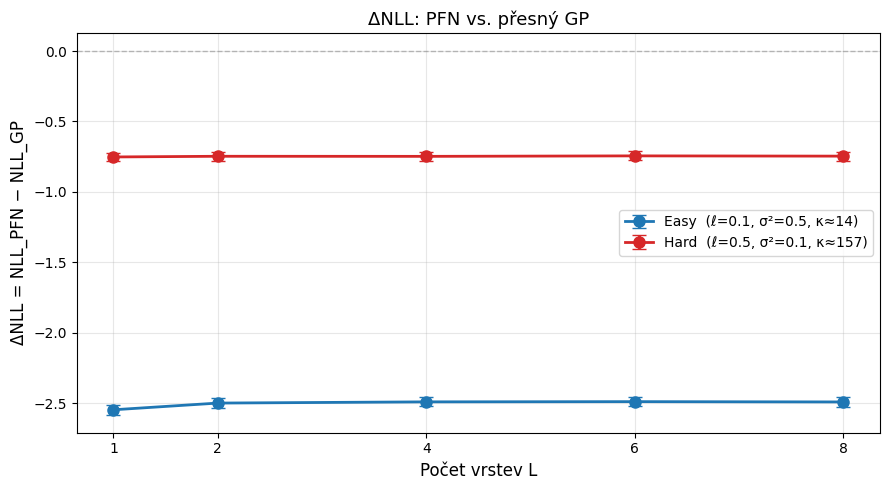

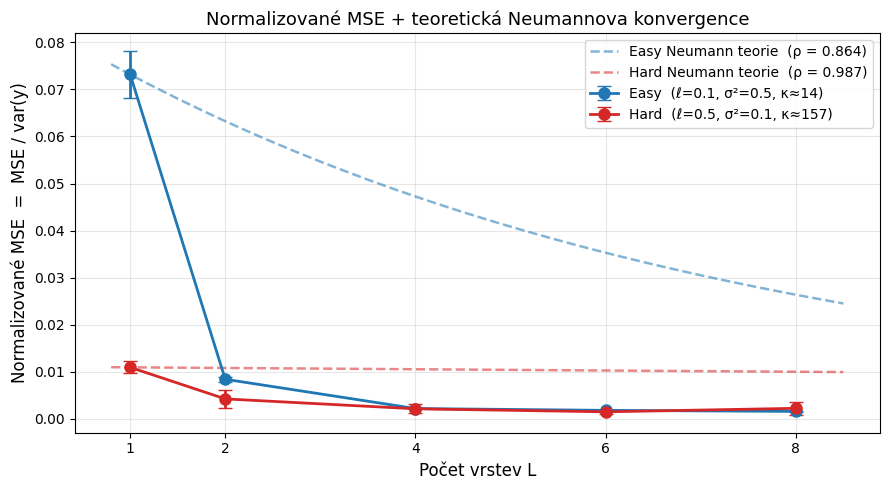


  Vrstvy   ΔNLL Easy   ΔNLL Hard   MSE Easy   MSE Hard   nMSE Easy   nMSE Hard
----------------------------------------------------------------------------
       1     -2.5479     -0.7524   0.088104   0.004020     0.07319     0.01091
       2     -2.5002     -0.7476   0.010483   0.003911     0.00837     0.00420
       4     -2.4915     -0.7481   0.002611   0.002004     0.00215     0.00209
       6     -2.4900     -0.7447   0.002342   0.000983     0.00176     0.00145
       8     -2.4921     -0.7466   0.001866   0.002564     0.00153     0.00220

=== MSE DEKOMPOZICE ===
Generuji datasety...

Počítám Easy modely...
  1-layer
  2-layer
  4-layer
  6-layer
  8-layer

Počítám Hard modely...
  1-layer
  2-layer
  4-layer
  6-layer
  8-layer


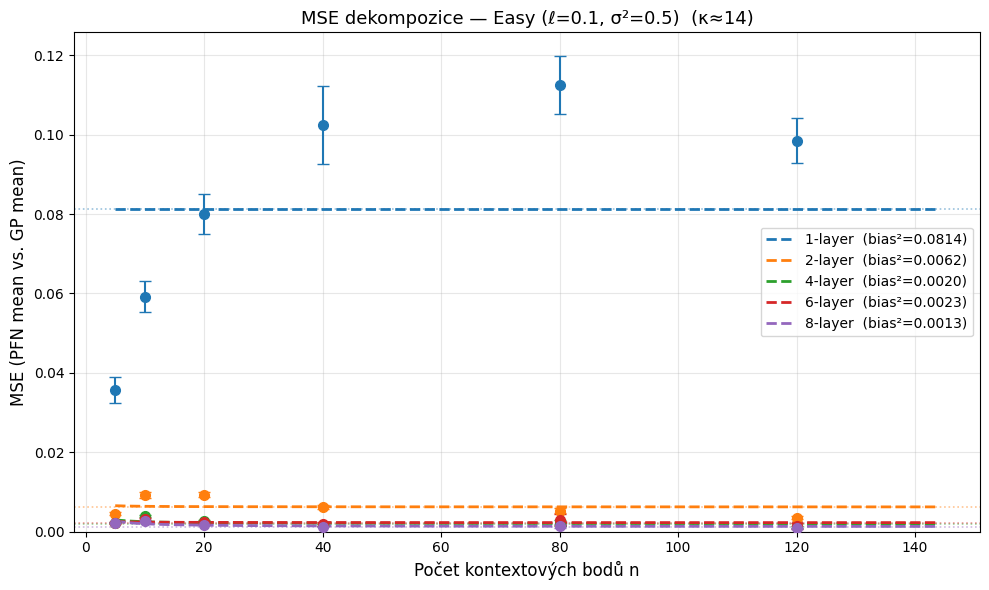


Model             bias²        c  Bias signifikantní?
---------------------------------------------
1-layer         0.08137    0.000  ANO
2-layer         0.00622    0.002  ANO
4-layer         0.00200    0.005  ANO
6-layer         0.00226    0.001  ANO
8-layer         0.00127    0.007  ANO


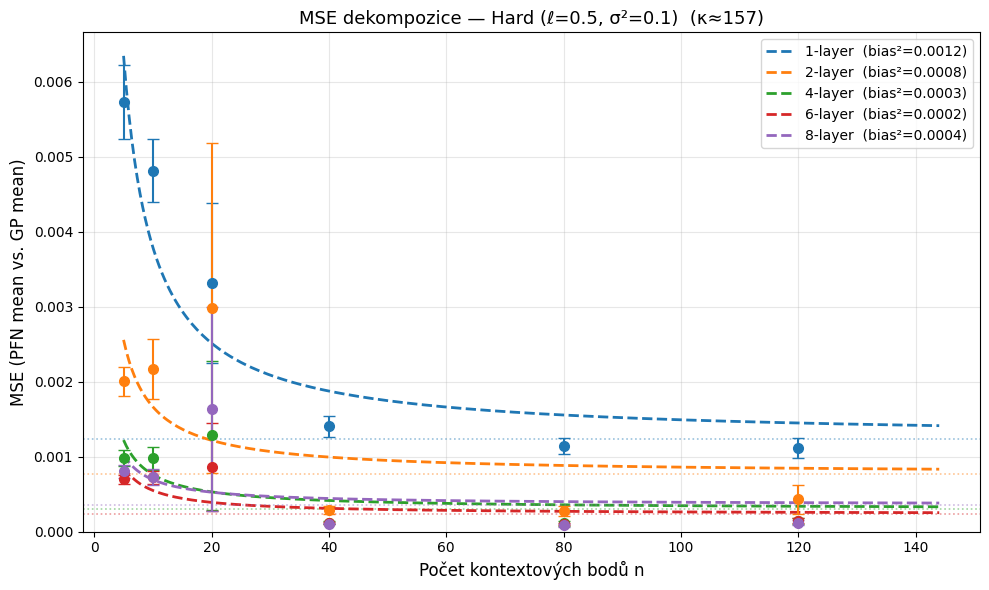


Model             bias²        c  Bias signifikantní?
---------------------------------------------
1-layer         0.00124    0.026  ANO
2-layer         0.00077    0.009  ne
4-layer         0.00030    0.005  ne
6-layer         0.00023    0.003  ne
8-layer         0.00036    0.003  ne


In [7]:
# =============================================
# SPUŠTĚNÍ EXPERIMENTU
# =============================================

print('=== EASY modely na Easy datech ===')
easy_results = run_experiment(EASY_MODELS, easy_datasets, EASY_HPS, label='[Easy]')

print('\n=== HARD modely na Hard datech ===')
hard_results = run_experiment(HARD_MODELS, hard_datasets, HARD_HPS, label='[Hard]')

# Grafy
plot_results(easy_results, hard_results, metric='delta_nll')
plot_results(easy_results, hard_results, metric='norm_mse')  # normalizované MSE + Neumann teorie

# Tabulka
print_table(easy_results, hard_results)


# =============================================
# MSE DEKOMPOZICE
# =============================================
N_VALUES       = [5, 10, 20, 40, 80, 120]
N_TEST_DECOMP  = 10
N_INST_DECOMP  = 200

print('\n=== MSE DEKOMPOZICE ===')
print('Generuji datasety...')
mse_ds_easy = generate_mse_decomp_datasets(N_VALUES, N_TEST_DECOMP, N_INST_DECOMP, EASY_HPS)
mse_ds_hard = generate_mse_decomp_datasets(N_VALUES, N_TEST_DECOMP, N_INST_DECOMP, HARD_HPS)

print('\nPočítám Easy modely...')
all_mse_easy = {}
for name, model in EASY_MODELS.items():
    print(f'  {name}')
    all_mse_easy[name] = compute_mse_decomposition(model, mse_ds_easy, EASY_HPS, device)

print('\nPočítám Hard modely...')
all_mse_hard = {}
for name, model in HARD_MODELS.items():
    print(f'  {name}')
    all_mse_hard[name] = compute_mse_decomposition(model, mse_ds_hard, HARD_HPS, device)

plot_mse_decomposition(all_mse_easy, EASY_HPS, kappa_easy,
    title=f'MSE dekompozice — Easy (ℓ={EASY_HPS["lengthscale"]}, σ²={EASY_HPS["noise"]})')
plot_mse_decomposition(all_mse_hard, HARD_HPS, kappa_hard,
    title=f'MSE dekompozice — Hard (ℓ={HARD_HPS["lengthscale"]}, σ²={HARD_HPS["noise"]})')


## MSE dekompozice: bias² + c/n

### Co vidíme v grafu

**Osa X:** počet kontextových bodů $n$  
**Osa Y:** MSE(PFN mean, GP mean)

$$\text{MSE}(n) \approx \text{bias}^2 + \frac{c}{n}$$

- **$c/n$** — variační složka: klesá s více kontextovými body
- **$\text{bias}^2$** — ireducibilní chyba: asymptota pro $n \to \infty$; měří jak daleko je model od GP posterioru i s nekonečným kontextem

Tečkované vodorovné čáry = bias² každého modelu.

### Klíčová predikce (Neumannova hypotéza)
- **Easy** (malá κ): bias² klesá rychle s počtem vrstev; 1–2 vrstvy mohou stačit
- **Hard** (velká κ): bias² klesá pomaleji; modely s méně vrstvami mají větší ireducibilní chybu


## Interpretace výsledků

### ΔNLL → 0 znamená: PFN ≈ optimální Bayesovská predikce
ΔNLL = 0 nastane, pokud PFN perfektně reprodukuje GP posterior distribuci.
Kladné ΔNLL = PFN je horší než GP; záporné by znamenalo přefit (neočekávané).

### MSE → 0 znamená: střední hodnota PFN ≈ GP posterior mean
MSE měří pouze chybu středu predikce, ne celou distribuci.

### Neumannova hypotéza
Pokud platí, Easy (malá κ) by měla dosáhnout nízkého ΔNLL/MSE při méně vrstvách než Hard (velká κ).
Interpretace podmíněnosti κ vypočtené výše:
- Easy κ ≈ {kappa_easy:.0f} → míra konvergence GD za krok: {(kappa_easy-1)/(kappa_easy+1):.3f}
- Hard κ ≈ {kappa_hard:.0f} → míra konvergence GD za krok: {(kappa_hard-1)/(kappa_hard+1):.3f}
